In [3]:
#!pip install boto3 matplotlib

In [4]:
import boto3
import json

# 1. Vi skapar två "fjärrkontroller": en för att titta i bucketen (S3) och en för AI:n (Rekognition)
s3_klient = boto3.client('s3')

# OBS: Se till att regionen matchar där du skapade din bucket! (t.ex. 'eu-west-1')
rekognition_klient = boto3.client('rekognition', region_name='eu-west-1') 

# Byt ut detta mot namnet på din bucket!
min_bucket = 'tommie-aws-bucket-792936252601-eu-west-1-an'

# 2. Hämta en lista över alla bilder du har i bucketen
print(f"Letar efter bilder i {min_bucket}...")
svar_fran_s3 = s3_klient.list_objects_v2(Bucket=min_bucket)

# Vi plockar ut namnen (Key) på alla filer vi hittade
bild_namn_lista = []
if 'Contents' in svar_fran_s3:
    for fil in svar_fran_s3['Contents']:
        bild_namn_lista.append(fil['Key'])

print(f"Hittade {len(bild_namn_lista)} bilder! Nu startar vi AI-analysen...")

# En tom lista för att spara alla etiketter som AI:n hittar
alla_hittade_etiketter = []

# 3. Nu ber vi Rekognition att titta på varje bild, en i taget
for bild_namn in bild_namn_lista:
    
    # Det här är det magiska anropet till AWS AI!
    ai_svar = rekognition_klient.detect_labels(
        Image={
            'S3Object': {
                'Bucket': min_bucket,
                'Name': bild_namn
            }
        },
        MaxLabels=5,        # Vi ber om max 5 etiketter per bild (för att hålla det simpelt)
        MinConfidence=80    # AI:n måste vara minst 80% säker
    )
    
    # AI:n svarar med mycket information, vi plockar bara ut namnen på etiketterna
    for etikett in ai_svar['Labels']:
        alla_hittade_etiketter.append(etikett['Name'])

# 4. Spara allt till en lokal fil (så vi inte behöver köra AI:n igen om vi vill rita om diagrammet)
with open('mina_etiketter.json', 'w') as fil:
    json.dump(alla_hittade_etiketter, fil)

print("Analysen är helt klar! Resultatet har sparats i 'mina_etiketter.json'.")

Letar efter bilder i tommie-aws-bucket-792936252601-eu-west-1-an...
Hittade 50 bilder! Nu startar vi AI-analysen...
Analysen är helt klar! Resultatet har sparats i 'mina_etiketter.json'.


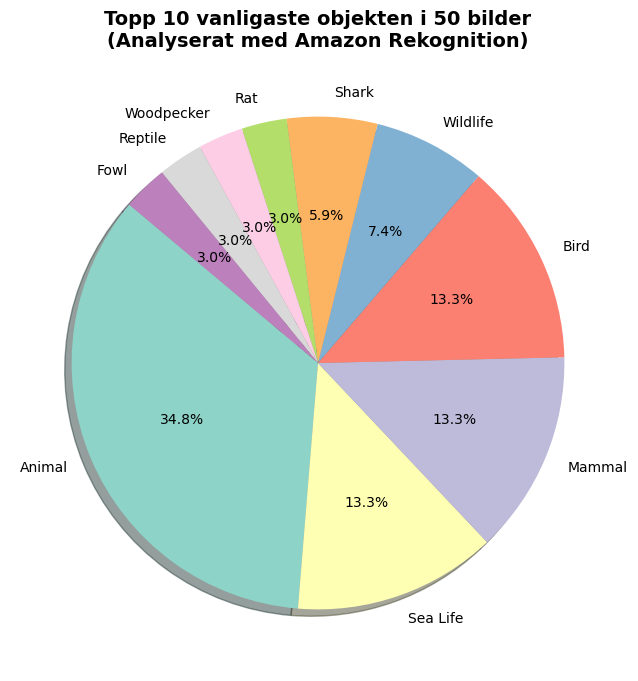

In [5]:
import json
from collections import Counter
import matplotlib.pyplot as plt

# 1. Läs in datan från filen vi just skapade
with open('mina_etiketter.json', 'r') as fil:
    alla_etiketter = json.load(fil)

# 2. Räkna hur vanligt förekommande varje upptäckt är
# (Counter är ett fantastiskt BI-verktyg i Python som grupperar och räknar direkt)
rakning = Counter(alla_etiketter)

# Vi plockar ut de 10 vanligaste objekten för att diagrammet ska bli tydligt
topp_10 = rakning.most_common(10)

# Separera namnen på etiketterna och antalet i två olika listor
etikett_namn = [sak[0] for sak in topp_10]
etikett_antal = [sak[1] for sak in topp_10]

# 3. Skapa själva cirkeldiagrammet
plt.figure(figsize=(10, 8))

# Rita kakan (pie chart)
plt.pie(etikett_antal, 
        labels=etikett_namn, 
        autopct='%1.1f%%',  # Skriver ut procenttalet med 1 decimal
        startangle=140, 
        shadow=True, 
        colors=plt.cm.Set3.colors) # Ger fina pastellfärger

plt.title('Topp 10 vanligaste objekten i 50 bilder\n(Analyserat med Amazon Rekognition)', fontsize=14, fontweight='bold')

# Spara diagrammet som en PNG-bild, redo att lämnas in i skolan!
plt.savefig('mitt_cirkeldiagram.png', bbox_inches='tight')

# Visa diagrammet på skärmen
plt.show()